In [1]:
# Check venv matches:
# C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe
import sys
print(sys.executable)

C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe


In [2]:
# imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Make pandas usable for wide MTG data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 0)

In [30]:
# confirm path to data
PROJECT_ROOT = Path("../..").resolve()
print(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data" / "processed"
CARDS_CORE_PATH = DATA_DIR / "cards_core.parquet"
print(CARDS_CORE_PATH)

# Load parquet to dataframe
cards_core = pd.read_parquet(CARDS_CORE_PATH)
# Basic shape and schema
print(cards_core.shape)
cards_core.head(1)

C:\Users\mitch\source\repos\mtg_ai
C:\Users\mitch\source\repos\mtg_ai\data\processed\cards_core.parquet
(37384, 19)


,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness
0,a471b306-4941-4e46-a0cb-d92895c16f8a,00037840-6089-42ec-8c5c-281f9f474504,"Nissa, Worldsoul Speaker",2025-02-14,en,normal,Legendary Creature — Elf Druid,"Landfall — Whenever a land you control enters, you get {E}{E} (two energy counters).\nYou may pay eight {E} rather t...",{3}{G},[G],[G],[Landfall],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...",drc,Aetherdrift Commander,rare,4.0,3,3


In [5]:
cards_core.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37384 entries, 0 to 37383
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              37384 non-null  object        
 1   oracle_id       37384 non-null  object        
 2   name            37384 non-null  object        
 3   released_at     37384 non-null  datetime64[ns]
 4   lang            37384 non-null  object        
 5   layout          37384 non-null  object        
 6   type_line       37384 non-null  object        
 7   oracle_text     34258 non-null  object        
 8   mana_cost       34618 non-null  object        
 9   colors          34618 non-null  object        
 10  color_identity  37384 non-null  object        
 11  keywords        37384 non-null  object        
 12  legalities      37384 non-null  object        
 13  set             37384 non-null  object        
 14  set_name        37384 non-null  object        
 15  ra

In [6]:
# define functions for later formatting

COLOR_ORDER = ["W", "U", "B", "R", "G"]
COLOR_RANK = {color: i for i, color in enumerate(COLOR_ORDER)}

def normalize_color_identity(x):
    if isinstance(x, np.ndarray):
        return list(x)

    if isinstance(x, list):
        return x

    if x is None:
        return []

    return []

def normalize_color_array(x):
    if isinstance(x, np.ndarray):
        return list(x)

    if isinstance(x, list):
        return x

    if x is None:
        return []

    return []

def color_combo_to_string(colors):
    colors = normalize_color_array(colors)

    if len(colors) == 0:
        return "Colorless"

    ordered = sorted(colors, key=lambda c: COLOR_RANK.get(c, 99))
    return "".join(ordered)

def combo_sort_key(combo):
    if combo == "Colorless":
        return (0, 0, [])

    return (
        1,
        len(combo),
        [COLOR_RANK.get(c, 99) for c in combo]
    )

In [8]:
# Missing values

missing = cards_core.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

toughness      18228
power          18228
oracle_text     3126
colors          2766
mana_cost       2766
dtype: int64

In [31]:
# Unique counts

key_cols = ["id", "oracle_id", "name"]
for col in key_cols:
    print(f"{col}: {cards_core[col].nunique():,} unique values")

id: 37,384 unique values
oracle_id: 37,384 unique values
name: 36,909 unique values


In [10]:
# Unhashable columns

problem_cols = []

for col in cards_core.columns:
    has_unhashable = cards_core[col].apply(
        lambda x: isinstance(x, (list, dict, set, np.ndarray))
    ).any()
    
    if has_unhashable:
        problem_cols.append(col)

problem_cols

['colors', 'color_identity', 'keywords', 'legalities']

In [32]:
# Check for duplicate rows (using hashable cols)

scalar_cols = [
    col for col in cards_core.columns
    if col not in problem_cols
]

dup_rows = cards_core.duplicated(subset=scalar_cols).sum()
dup_rows

np.int64(0)

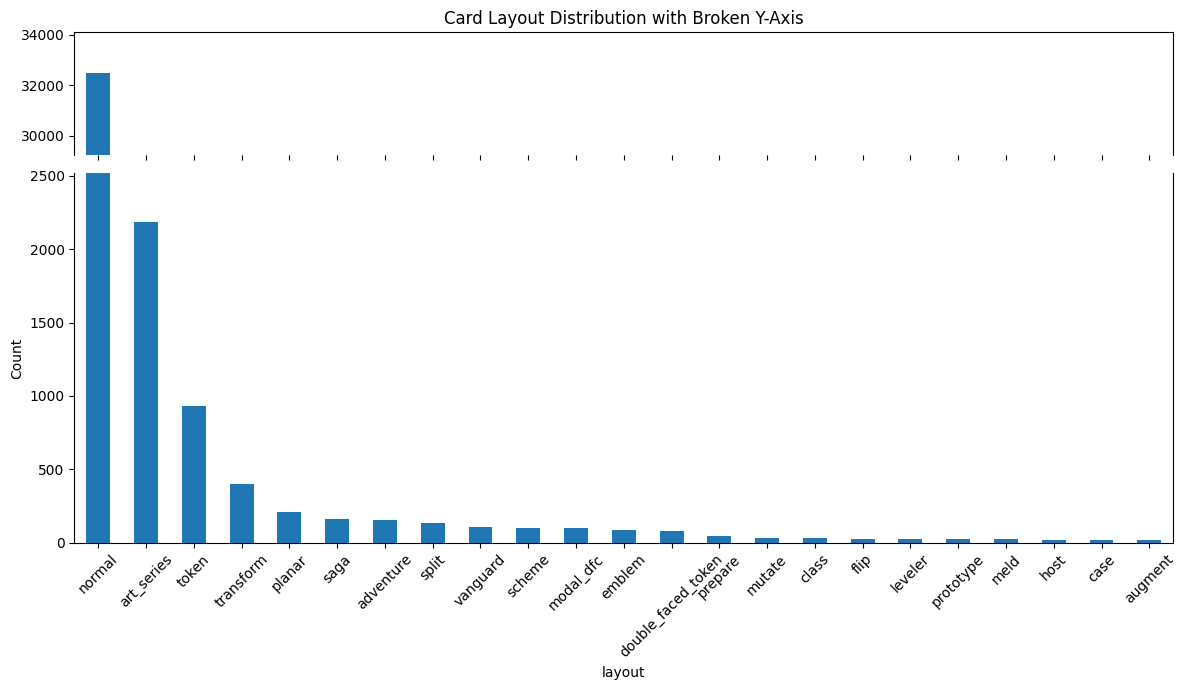

In [36]:
# Card Layout distributions

layout_counts = cards_core["layout"].value_counts()

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(12, 7),
    gridspec_kw={"height_ratios": [1, 3]}
)

layout_counts.plot(kind="bar", ax=ax_top)
layout_counts.plot(kind="bar", ax=ax_bottom)

# Find the largest non-normal layout count.
non_normal_counts = layout_counts.drop(labels=["normal"], errors="ignore")
max_non_normal = non_normal_counts.max()

# Top axis shows the normal-layout peak.
ax_top.set_ylim(layout_counts.max() * 0.90, layout_counts.max() * 1.05)

# Bottom axis shows variation among all lower-count layouts.
ax_bottom.set_ylim(0, max_non_normal * 1.15)

ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)

ax_top.tick_params(labeltop=False)
ax_bottom.tick_params(axis="x", rotation=45)

ax_top.set_title("Card Layout Distribution with Broken Y-Axis")
ax_bottom.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [37]:
# Examples of cards in each layout

non_normal_layouts = layout_counts.index.tolist()
non_normal_layouts = [l for l in non_normal_layouts if l != "normal"]

for layout in non_normal_layouts:
    print(f"\n--- Layout: {layout} ---")
    display(cards_core[cards_core["layout"] == layout].head(1))


--- Layout: art_series ---


,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness
14,625a41c8-0b5a-4738-afa6-db847d043c88,0019beff-1528-4131-ae21-9e7a3cf7fbfb,Brightglass Gearhulk // Brightglass Gearhulk,2025-02-14,en,art_series,Card // Card,None,None,None,[],[],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'not_legal', 'duel': 'not_legal', 'future': 'not_legal',...",adft,Aetherdrift Art Series,common,0.0,None,None



--- Layout: token ---


,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness
38,21afb029-9aef-4e6e-a646-3343605b4bb7,0042a526-8828-40eb-bd32-4f57b230625a,Tyranid,2022-10-07,en,token,Token Creature — Tyranid,,,[G],[G],[],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'not_legal', 'duel': 'not_legal', 'future': 'not_legal',...",t40k,"Warhammer 40,000 Tokens",common,0.0,5,5



--- Layout: transform ---


...

,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness
1235,71eae1cf-f7e8-4281-a50c-fc4b728d23dd,085db4e5-74a0-494d-8cc3-4ec4c64cea6e,Labro Bot,2017-12-08,en,host,Host Artifact Creature — Dog,"When this creature enters, return target host card or card with augment from your graveyard to your hand.",{5},[],[],[],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'not_legal', 'duel': 'not_legal', 'future': 'not_legal',...",ust,Unstable,uncommon,5.0,3,3



--- Layout: case ---


,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness
1992,ac63941b-3f78-4bd3-8b05-ca12aaaa006c,0d8730b5-f7ba-48b0-928d-d8b7685347d3,Case of the Uneaten Feast,2024-02-09,en,case,Enchantment — Case,"Whenever a creature you control enters, you gain 1 life.\nTo solve — You've gained 5 or more life this turn. (If uns...",{W},[W],[W],[Solved],"{'alchemy': 'not_legal', 'brawl': 'legal', 'commander': 'legal', 'duel': 'legal', 'future': 'legal', 'gladiator': 'l...",mkm,Murders at Karlov Manor,rare,1.0,None,None



--- Layout: augment ---


,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness
880,7cdb8d36-92e3-43b5-b9ce-79cb8d2bfd76,05c348e3-79f2-4193-863b-a64577839a97,Humming-,2020-02-29,en,augment,Creature — Bird,"Flying\nWhenever you attack with two or more creatures,\nAugment {3}{W} ({3}{W}, Reveal this card from your hand: Co...",,[W],[W],"[Flying, Augment]","{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'not_legal', 'duel': 'not_legal', 'future': 'not_legal',...",und,Unsanctioned,common,0.0,+2,+3


In [39]:
# Check languages in dataset

print(cards_core["lang"].value_counts().head(10))

lang
en    37376
ja        8
Name: count, dtype: int64


In [44]:
# Check for missing text

missing_oracle = cards_core["oracle_text"].isnull().sum()
print(f"Missing oracle_text: {missing_oracle:,}")

# Show examples where it's missing
# display(cards_core[cards_core["oracle_text"].isnull()].head(10))

Missing oracle_text: 3,126


In [45]:
# Check for duplicate card names

name_per_oracle = cards_core.groupby("oracle_id")["name"].nunique()
print("Max names per oracle_id:", name_per_oracle.max())

Max names per oracle_id: 1


In [42]:
# Check CMC values

cmc_counts = (
    cards_core["cmc"]
    .dropna()
    .round(0)
    .astype(int)
    .value_counts()
    .sort_index()
)

print(cmc_counts.index.tolist())
print(cmc_counts.index.min(), cmc_counts.index.max())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1000000]
0 1000000


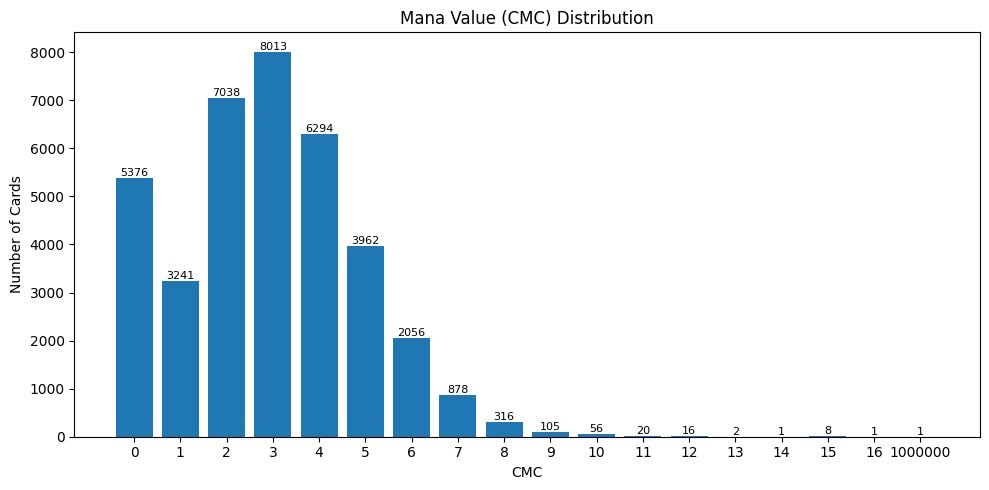

In [46]:
# Display CMC distribution

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(cmc_counts))
x_labels = cmc_counts.index.astype(str)
y_values = cmc_counts.values

bars = ax.bar(x_pos, y_values)

ax.set_title("Mana Value (CMC) Distribution")
ax.set_xlabel("CMC")
ax.set_ylabel("Number of Cards")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)

# Add labels on top of bars
for i, v in enumerate(y_values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
# Create hashable cols for colors

cards_core["color_identity_str"] = cards_core["color_identity"].apply(color_combo_to_string)
cards_core["colors_str"] = cards_core["colors"].apply(color_combo_to_string)

In [22]:
# Get color counts

color_counts = cards_core["color_identity_str"].value_counts()
colors_counts = cards_core["colors_str"].value_counts()

In [23]:
# Create a new DF for visualizizing color distrobutions

combined_df = pd.DataFrame({
    "Color Identity": color_counts,
    "Colors": colors_counts
}).fillna(0)

combined_df = combined_df.reset_index().rename(columns={"index": "Color Combination"})

combined_df["sort_key"] = combined_df["Color Combination"].apply(combo_sort_key)

combined_df = (
    combined_df
    .sort_values("sort_key")
    .drop(columns="sort_key")
    .set_index("Color Combination")
)

# combined_df

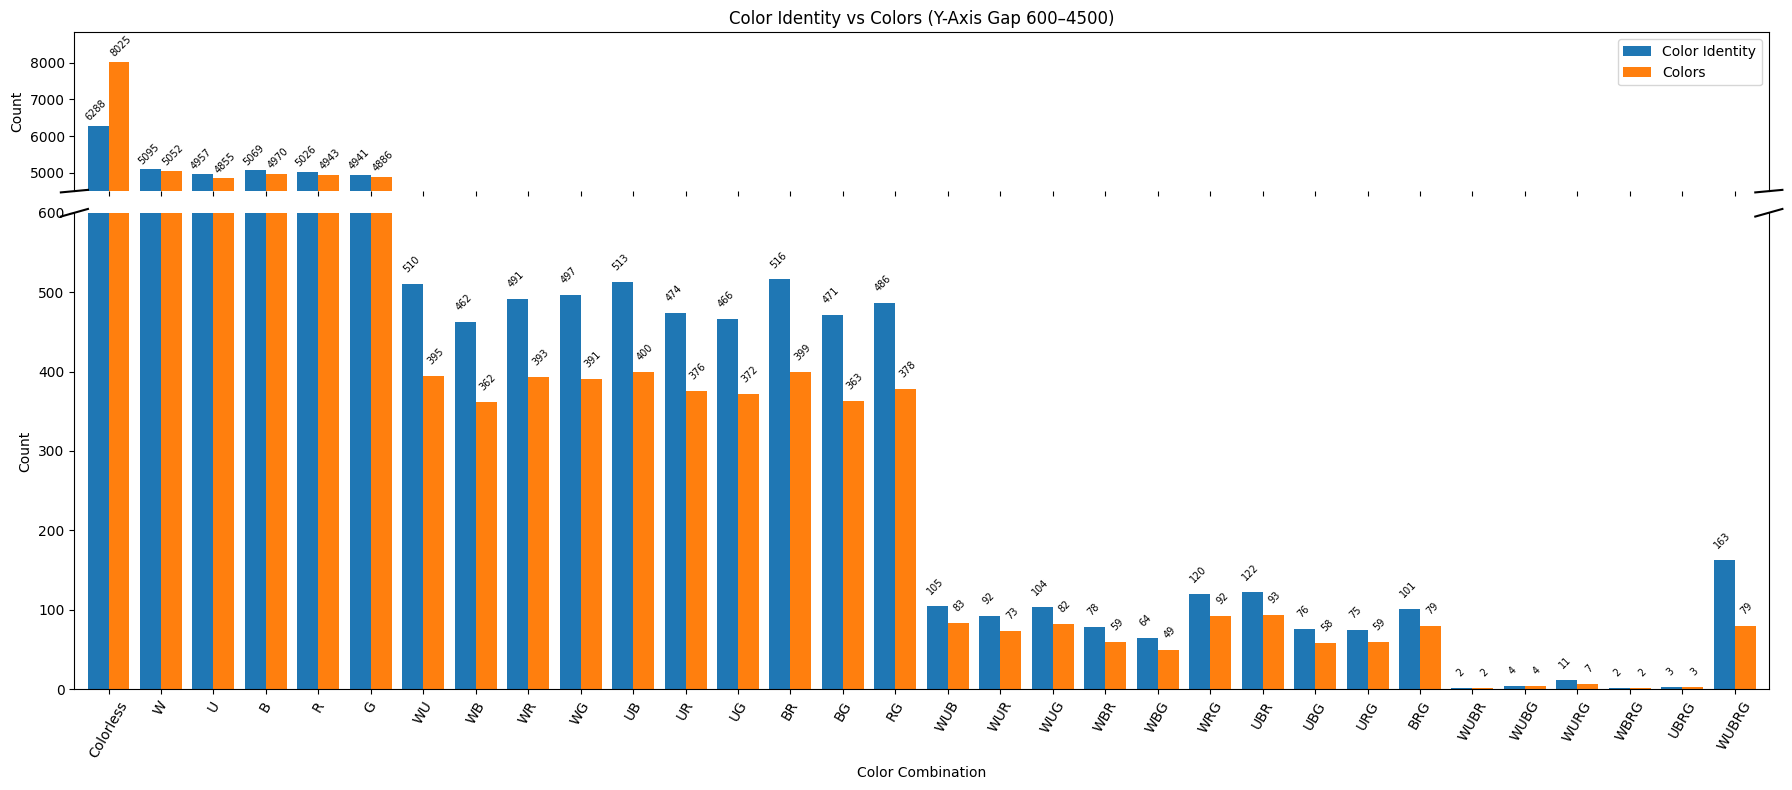

In [24]:
# Display colors graph

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(18, 8),
    gridspec_kw={"height_ratios": [1, 3]}
)

combined_df.plot(kind="bar", ax=ax_top, width=0.8)
combined_df.plot(kind="bar", ax=ax_bottom, width=0.8, legend=False)

# Define cut range
lower_max = 600
upper_min = 4500
max_count = combined_df.max().max()

# Apply limits
ax_bottom.set_ylim(0, lower_max)
ax_top.set_ylim(upper_min, max_count * 1.1)

# Hide spines
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)

ax_top.tick_params(labelbottom=False)
ax_bottom.tick_params(axis="x", rotation=60)

ax_top.set_title("Color Identity vs Colors (Y-Axis Gap 600–4500)")
ax_bottom.set_xlabel("Color Combination")
ax_top.set_ylabel("Count")
ax_bottom.set_ylabel("Count")

# Break marks
d = 0.008

kwargs = dict(transform=ax_top.transAxes, color="black", clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs = dict(transform=ax_bottom.transAxes, color="black", clip_on=False)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Value labels (45°)
for ax in [ax_top, ax_bottom]:
    for container_idx, container in enumerate(ax.containers):
        x_offset = -0.03 if container_idx == 0 else 0.03

        for bar in container:
            height = bar.get_height()

            if height > 0:
                y_min, y_max = ax.get_ylim()

                if y_min <= height <= y_max:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2 + x_offset,
                        height + (y_max - y_min) * 0.02,
                        f"{int(height)}",
                        ha="center",
                        va="bottom",
                        fontsize=7,
                        rotation=45
                    )

plt.tight_layout()
plt.show()

In [25]:
# 

type_counts = cards_core["type_line"].value_counts()
print(type_counts.head(15))

type_line
Instant                     3558
Sorcery                     3398
Card // Card                2220
Enchantment                 1821
Artifact                    1354
Enchantment — Aura          1181
Land                         782
Artifact — Equipment         516
Creature — Human Soldier     419
Creature — Human Wizard      404
Card                         342
Creature — Spirit            331
Creature — Elemental         330
Creature — Beast             289
Creature — Human Cleric      258
Name: count, dtype: int64


In [28]:
# 8. Data quality concerns


In [29]:
# Refactor recommendations

# Remove layouts:
    # art_series
    # token
    # planar
    # vanguard
    # scheme
    # emblem
    # double_faced_token
    # non-legal un-set cards
    # split-tokens

# Remove types:
    # token/tolkien
    # Card

# Process Keywords and Legalities 

# split raw dataset columns into smaller groups
    # Core Identifiers
    # Basic Card Info
    # Gameplay Characteristics
    # Colors & Identity
    # Legality & Formats
    # Set & Printing Info
    # Related / Special Data
    # Metadata & Flags
    # Misc